# **EXERCICI 2: SNPs i risc de malaltia**

## **Introducció: què estudiarem?**
El nostre genoma és un llibre de 3.200 milions de lletres. De vegades, en una posició concreta una persona té una G i una altra té una T. Això si succeeix en més d'un 1% de la població, s'anomena SNP (Single Nucleotide Polymorphism).

L'**objectiu d'avui**: Som detectius genètics. Tenim dades d'un centenar de persones i volem saber si algun d'aquests "canvis de lletres" (SNPs) està relacionat amb una malaltia.

## Conceptes claus

**1) SNP (Single Nucleotide Polymorphism)**

És un canvi en una sola lletra del DNA.
Per exemple:

Persona 1: AAG**G**CT

Persona 2: AAG**T**CT

Cada persona pot tenir:

* GG (homozigot)
* GT (heterozigot)
* TT (homozigot alternatiu)

**2) Cas vs Control**

A la nostra base de dades:

* `Case` = 1 → persona amb la malaltia

* `Case` = 0 → persona sense la malaltia

Volem veure si algun SNP està associat amb la malaltia.


**3) Models d'herència**

Un SNP pot actuar de diferents maneres:

* Model recessiu → només afecta si tens dues còpies del variant (TT)

* Model dominant → afecta si tens almenys una còpia (GT o TT)

Intentarem descobrir quin model encaixa millor amb les dades.

## **COMENCEM LA PRÀCTICA**

## Importem els paquets necessaris

Aquí carreguem les llibreries que ens permetran:

* Fer models estadístics
* Calcular probabilitats
* Fer gràfics
* Mesurar la qualitat del model

In [1]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import seaborn as sns

## Importem les dades (fitxer .txt)

In [30]:
link_data = "https://raw.githubusercontent.com/bsc-life/Bojos_supercomputacio/refs/heads/main/2026/data/snps_data.txt"

data = pd.read_csv(link_data, sep="\t", na_values=["NA"])

In [31]:
data.head()

,Case,SNP1,SNP2,SNP3
0,1,GT,GG,GT
1,1,TT,GT,GG
2,1,GT,GT,GG
3,1,GT,GT,TT
4,1,GG,TT,GT


Ara tenim una taula on:

* Cada fila és una persona
* Cada columna és un SNP o la variable Case

## PAS 1: Mirem proporcions

**Què fem?** Fem una *taula de contingència*. Mirem, per cada genotip (GG, GT, TT) quin percentatge de gent està malalta.

**Perquè ho fem?** Abans de fer matemàtiques complicades, hem de veure si hi ha un patró. Si veiem que el 80% dels "TT" estan malalts i només el 5% dels "GG" ho estan, ja tenim una pista boníssima!

In [32]:
pd.crosstab(data["SNP1"], data["Case"], normalize="index")

Case,0,1
SNP1,,
GG,0.655172,0.344828
GT,0.212766,0.787234
TT,0.208333,0.791667


In [33]:
pd.crosstab(data["SNP2"], data["Case"], normalize="index")

Case,0,1
SNP2,,
GG,0.407407,0.592593
GT,0.413043,0.586957
TT,0.148148,0.851852


In [34]:
pd.crosstab(data["SNP3"], data["Case"], normalize="index")

Case,0,1
SNP3,,
GG,0.333333,0.666667
GT,0.333333,0.666667
TT,0.360000,0.640000


**Preguntes**

* Hi ha algun SNP on només els TT tenen risc elevat? (Si és així, el patró és recessiu)
* Hi ha algun SNP on GT i TT tenen risc elevat? (Si és així, el patró és dominant)

## PAS 2: La Hipòtesi (Pensar abans d'actuar)

**Què fem?** Decidim quin model d'herència creiem que segueix cada SNP.

**Per què ho fem?** El mètode cièntific consisteix a predir i després comprovar. Si penses que és dominant, el teu model matemàtic ha d'agrupar els GT i els TT com si fossin el mateix grup de risc.

--> La ciència sempre comença amb una hipòtesi.

## PAS 3: Ajustem models matemàtics

**Què fem?** Farem un model matemàtic anomenat *regressió logística* amb la funció `smf.logit` de python.

Aquesta tècnica ens permet:

* Estimar la probabilitat de tenir la malaltia
* Veure com afecta el genotip
* Calcular mètriques objectives: Odds ratio i p-valor

### **CONCEPTE IMPORTANTS:**

---

**A) L'Odds Ratio (OR): Balança del risc**

L'OR ens diu quantes vegades és més probable que una persona amb una variant genètica estigui malalta en comparació amb una persona que no la té.

L’OR ens diu:
* OR = 1: El gen no fa res. El risc és el mateix.
* OR > 1: Risc augmentat. Si l'OR és 2, tens el doble de risc de tenir la malaltia.
* OR < 1: Efecte protector. El gen t'ajuda a NO tenir la malaltia.


**És el mateix OR que probabilitat?** No. L'OR és una comparació de "odds" (probabilitat de sí vs. probabilitat de no). La probabilitat és el risc absolut. L'OR ens diu quant canvia el risc, no quin risc total tens (pots tenir un OR de 10 i que la malaltia sigui tan rara que la teva probabilitat final segueixi sent baixa).

---
**B) El p-valor: El detector de mentides de l'atzar**
Imagina que tires una moneda 5 vegades i surten 5 cares. És una moneda trucada o ha estat sort? El p-valor calcula la probabilitat que els teus resultats siguin només fruit de l'atzar / casualitat.

* p < 0.05: Diem que és significatiu. Hi ha menys d'un 5% de probabilitat que sigui atzar. Ens ho creiem!

* p > 0.05: No podem descartar que sigui casualitat.

---

In [35]:
def calcular_stats_complets(data, snp_col, rare_allele):
    results = {}

    # --- MODEL DOMINANT ---
    data['dom'] = data[snp_col].apply(lambda x: 1 if rare_allele in x else 0)
    res_dom = smf.logit("Case ~ dom", data=data).fit(disp=0)
    results["Dominant_OR"] = np.exp(res_dom.params['dom'])
    results["Dominant_P"] = res_dom.pvalues['dom'] # <--- Captura del p-valor

    # --- MODEL RECESSIU ---
    rare_homo = rare_allele * 2
    data['rec'] = data[snp_col].apply(lambda x: 1 if x == rare_homo else 0)
    res_rec = smf.logit("Case ~ rec", data=data).fit(disp=0)
    results["Recessiu_OR"] = np.exp(res_rec.params['rec'])
    results["Recessiu_P"] = res_rec.pvalues['rec'] # <--- Captura del p-valor

    return results

In [36]:
# Calculem per als 3 SNPs
stats_snp1 = calcular_stats_complets(data, 'SNP1', 'T')
stats_snp2 = calcular_stats_complets(data, 'SNP2', 'T')
stats_snp3 = calcular_stats_complets(data, 'SNP3', 'T')

In [25]:
stats_snp1

{'Dominant_OR': np.float64(7.093333333333334),
 'Dominant_P': np.float64(5.7456185359710525e-05),
 'Recessiu_OR': np.float64(2.3446808510638313),
 'Recessiu_P': np.float64(0.1249084342291687)}

In [26]:
stats_snp2

{'Dominant_OR': np.float64(1.4945652173913044),
 'Dominant_P': np.float64(0.3882246285651313),
 'Recessiu_OR': np.float64(4.011627906976747),
 'Recessiu_P': np.float64(0.01887727690362037)}

In [27]:
stats_snp3

{'Dominant_OR': np.float64(0.9615384615384619),
 'Dominant_P': np.float64(0.9369667862474893),
 'Recessiu_OR': np.float64(0.8888888888888888),
 'Recessiu_P': np.float64(0.8074716628875092)}

In [37]:
# Creem un DataFrame per mostrar-ho netament
resum_final = pd.DataFrame([stats_snp1, stats_snp2, stats_snp3],
                          index=["SNP1", "SNP2", "SNP3"])

# Arrodonim per a una millor lectura
print("🔬 RESULTATS DE L'ESTUDI D'ASSOCIACIÓ:")
print(resum_final.round(4))

🔬 RESULTATS DE L'ESTUDI D'ASSOCIACIÓ:
      Dominant_OR  Dominant_P  Recessiu_OR  Recessiu_P
SNP1       7.0933      0.0001       2.3447      0.1249
SNP2       1.4946      0.3882       4.0116      0.0189
SNP3       0.9615      0.9370       0.8889      0.8075


**Preguntes**

* Si OR = 7, què vol dir?
* Si OR = 0.9, què vol dir?

## PAS 4: Visualitzem els resultats

Aquest gràfic és el resum de tota la nostra investigació. En ell comparem les dues "teories" (models d'herència) per a cada SNP i decidim quina és la que millor explica la malaltia.

* **L'Eix Y (Odds Ratio):** Ens indica la força del risc. Com més alta és la barra, més risc tenen les persones amb la variant "T". Recordeu que la línia discontínua a l'1 marca la neutralitat (sense risc).

* **Els Colors (Les dues teories)**:

  * **Blau (Model Recessiu):** Suposem que només els que tenen la variant doble (TT) estan en risc.

  * **Taronja (Model Dominant):** Suposem que tenir una sola lletra (GT) ja és suficient per augmentar el risc.

* **Les anotacions (p-valors i estrelles):** A sobre de cada barra veiem el "certificat de qualitat" estadística.

  * p < 0.05 o estrelles (*, **, ***): El resultat és fiable, no és atzar.

  * "ns" (no significatiu): La barra pot ser alta, però no ens en podem fiar; podria ser casualitat.


**Com decidir quin és el model correcte?**

Per a cada SNP, hem de buscar la barra que compleixi dues condicions:

  * Que sigui **la més alta** (major efecte).

  * Que tingui el **p-valor més petit** (més estrelles).

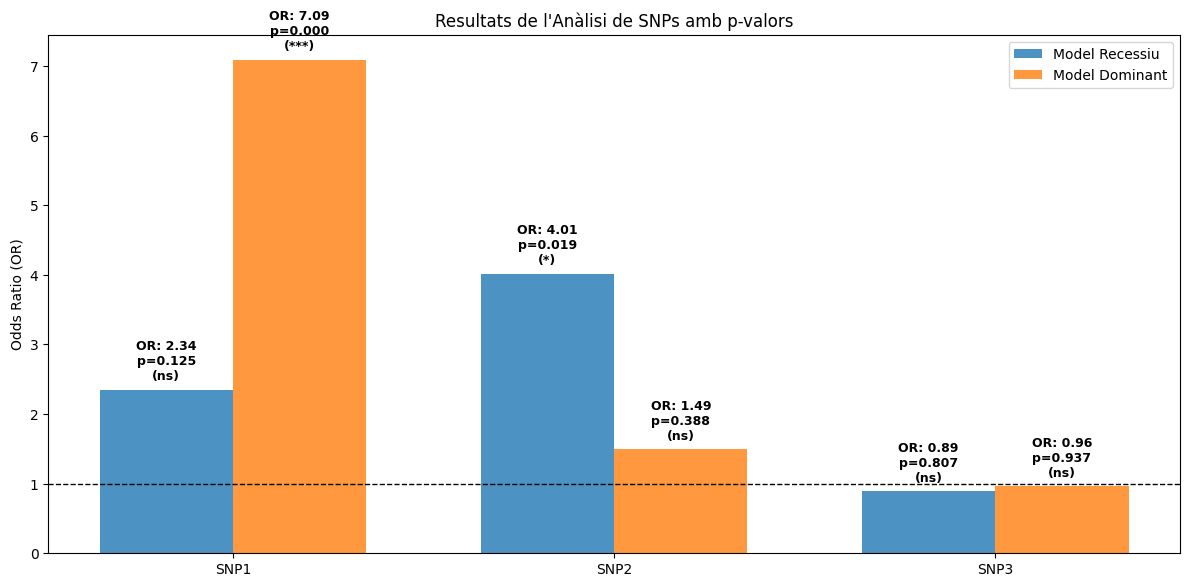

In [29]:
results_list = [stats_snp1, stats_snp2, stats_snp3]
labels = ["SNP1", "SNP2", "SNP3"]
recessiu_or = [r["Recessiu_OR"] for r in results_list]
dominant_or = [r["Dominant_OR"] for r in results_list]
recessiu_p = [r["Recessiu_P"] for r in results_list]
dominant_p = [r["Dominant_P"] for r in results_list]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
bars1 = ax.bar(x - width/2, recessiu_or, width, label='Model Recessiu', color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x + width/2, dominant_or, width, label='Model Dominant', color='#ff7f0e', alpha=0.8)

ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Odds Ratio (OR)')
ax.set_title("Resultats de l'Anàlisi de SNPs amb p-valors")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Funció per posar text d'OR i p-valor
def annotate_bars(bars, p_values):
    for bar, p in zip(bars, p_values):
        height = bar.get_height()
        significacio = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        ax.annotate(f'OR: {height:.2f}\np={p:.3f}\n({significacio})',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

annotate_bars(bars1, recessiu_p)
annotate_bars(bars2, dominant_p)

plt.tight_layout()
plt.show()

**Preguntes finals de reflexió**

* Quin SNP sembla estar associat amb la malaltia?
* Quin model encaixa millor per cada SNP?
* Podem afirmar causalitat o només associació?
* Què necessitaríem per demostrar causalitat?

### **Si tinguéssim milers de SNPs, què canviaria?**


**CONCEPTE IMPORTANT: Correcció per múltiples tests (FDR): "El filtre anti-falsos positius"**

Aquesta és la part més important de la genètica moderna. Si analitzes un sol SNP, un p-valor de 0.05 està bé. Però si analitzes 1 milió de SNPs, l'atzar t'enganyarà milers de vegades per pura probabilitat (falsos positius).

El FDR (False Discovery Rate) és un mètode matemàtic que "castiga" els p-valors quan fem moltes preguntes a la vegada, assegurant que el que trobem sigui realment sòlid i evitant que donem per bona una associació que és pur soroll estadístic.

És a dir, és com un filtre que ajusta els p-valors perquè només els SNPs realment importants passin la prova,


Això és el que es fa amb el **GWAS (Genome-Wide Association Studies)**

On s'analitzen milions de SNPs al llarg del genoma per veure quins estan associats amb malalties.

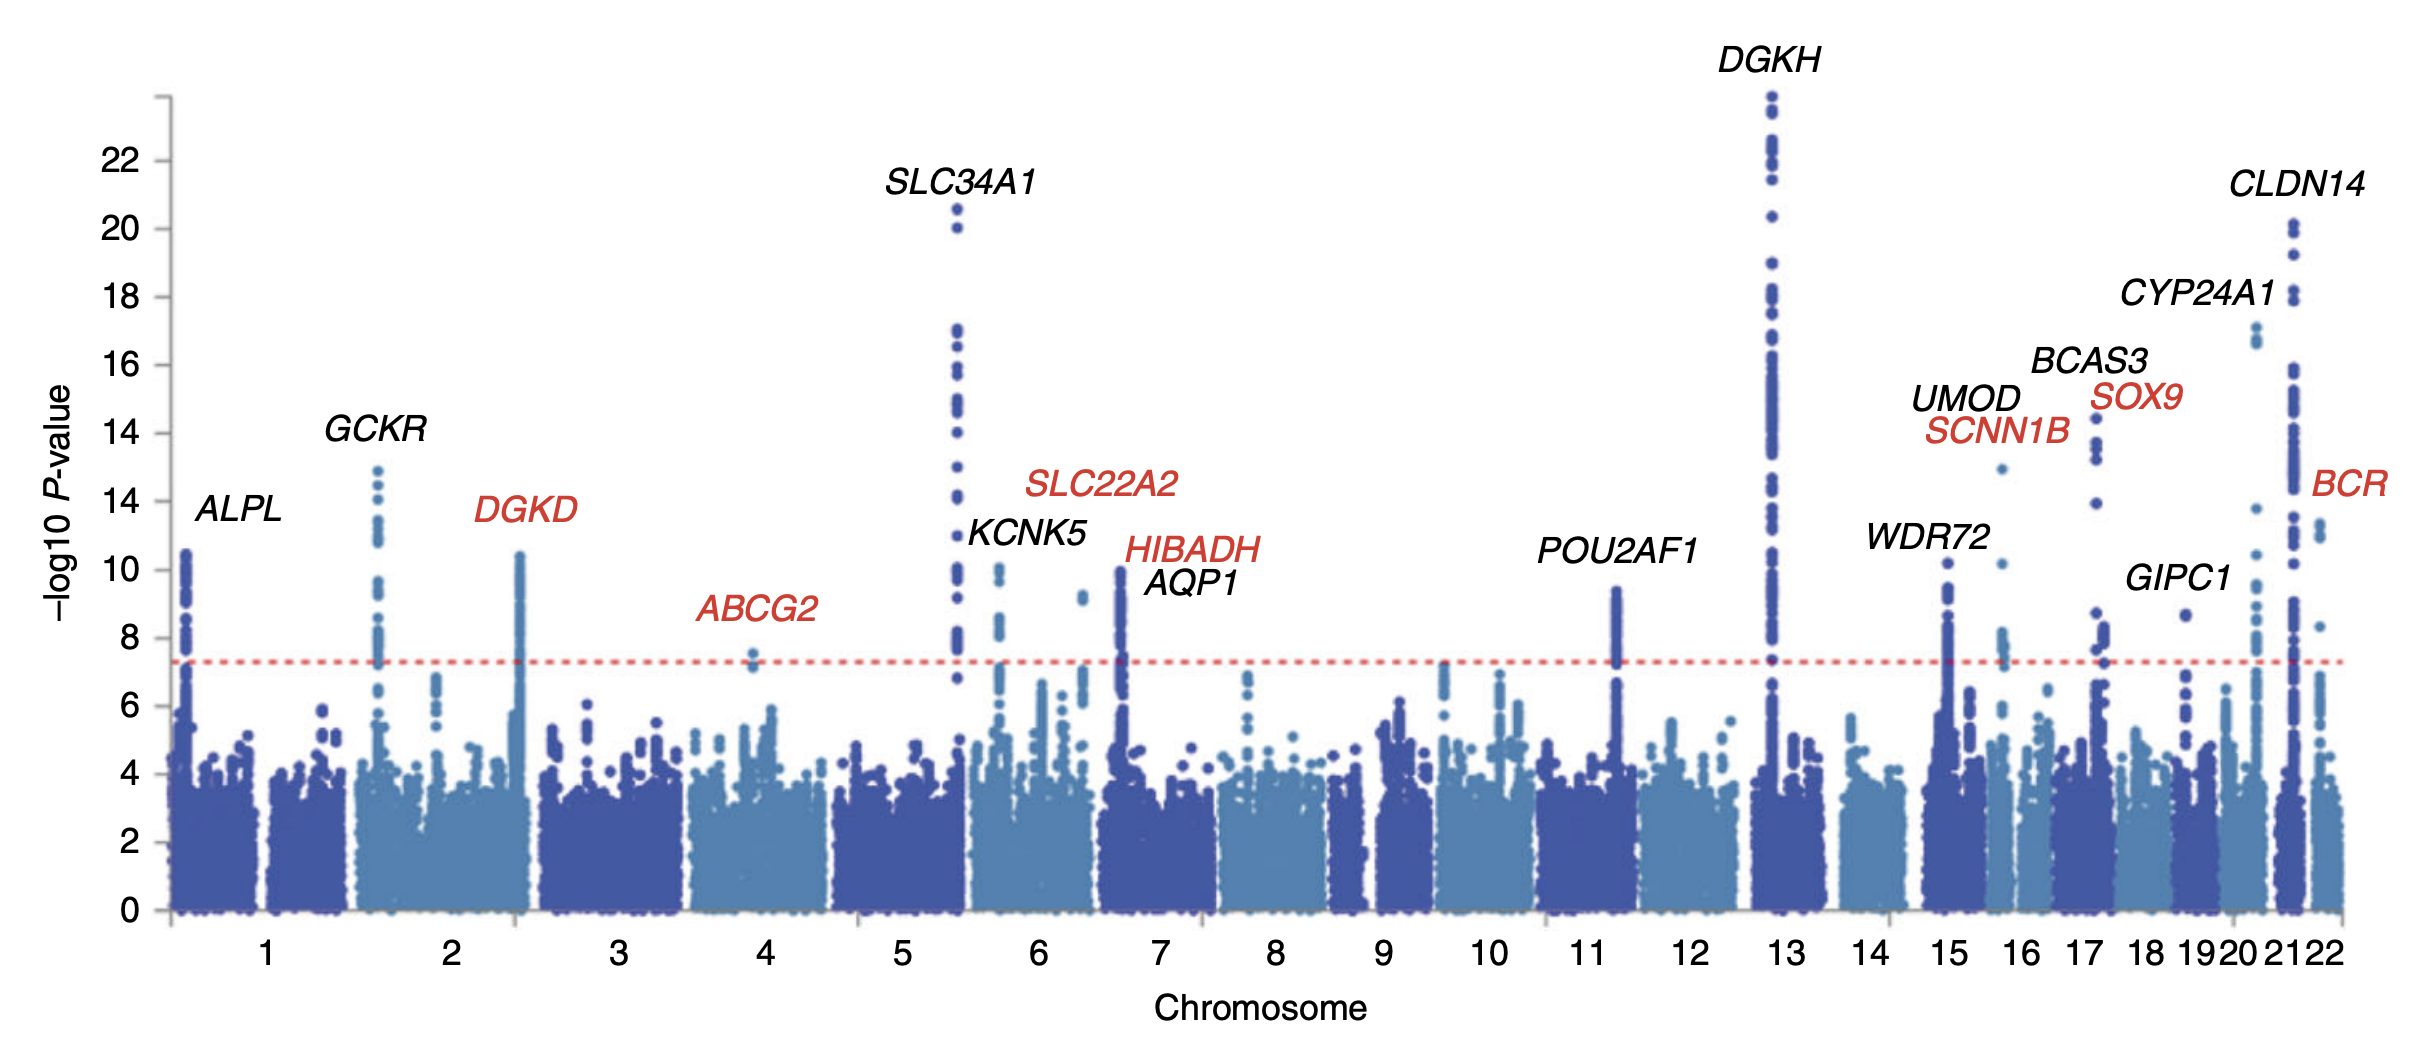

# **Missatge final**

En aquesta pràctica heu fet el que fan:

* Genetistes
* Bioinformàtics
* Investigadors biomèdics

Heu:

* Explorat dades
* Formulat hipòtesis
* Ajustat models matemàtics
* Interpretat resultats biològics

Això és ciència real!!